In [8]:
%matplotlib inline

## 1. Importación de librerías

En esta sección se importan las librerías necesarias para el entrenamiento, validación y análisis del modelo de detección. Se utiliza la librería `ultralytics` para trabajar con YOLOv8, además de herramientas auxiliares para la visualización de resultados, lectura de métricas y procesamiento de imágenes.

In [2]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
import os
import cv2

## 2. Configuración del modelo y rutas del proyecto

En esta sección se definen las rutas y parámetros principales que serán utilizados durante el entrenamiento. Se especifica la ubicación del archivo `data.yaml`, el modelo base YOLOv8 a utilizar y el nombre del experimento donde se guardarán los resultados generados.

In [3]:
DATASET_PATH = "dataset/data.yaml"
MODEL_BASE = "yolov8s.pt"
PROJECT_NAME = "deteccion_robo"

model = YOLO(MODEL_BASE)

## 3. Entrenamiento del modelo YOLOv8

En esta sección se realiza el entrenamiento del modelo YOLOv8 utilizando el dataset configurado previamente. Se establecen los principales parámetros de entrenamiento, como el número de épocas, el tamaño de imagen, el tamaño de lote y la paciencia para detener el entrenamiento si no se observan mejoras.

In [ ]:
results = model.train(
    data=DATASET_PATH,
    epochs=50,
    imgsz=640,
    batch=8,
    patience=10,
    name=PROJECT_NAME
)

## 4. Validación del modelo entrenado

En esta sección se carga el mejor modelo generado durante el entrenamiento y se realiza la validación utilizando el conjunto de datos definido en el archivo `data.yaml`. Esta etapa permite evaluar el rendimiento del modelo a partir de métricas como precisión, recall y mAP.

In [4]:
model = YOLO("runs/detect/deteccion_robo/weights/best.pt")

metrics = model.val(
    data="dataset/data.yaml",
    imgsz=640
)

Ultralytics 8.4.51  Python-3.10.4 torch-2.12.0+cpu CPU (AMD Ryzen 5 5600 6-Core Processor)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 378.3302.9 MB/s, size: 55.9 KB)
val: Scanning C:\Users\User\Desktop\EXP4\dataset\valid\labels.cache... 167 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 167/167  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.4s/it 15.1s1.5s
                   all        167        168      0.894      0.957      0.969      0.877
                normal        101        102      0.892      0.975      0.987      0.986
                  robo         66         66      0.895      0.939      0.951      0.769
Speed: 0.7ms preprocess, 84.4ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to C:\Users\User\Desktop\EXP4\runs\detect\val


## 5. Lectura de métricas del entrenamiento

En esta sección se carga el archivo `results.csv` generado automáticamente por YOLOv8 durante el entrenamiento. Este archivo contiene las métricas obtenidas en cada época, como las pérdidas del modelo y los valores de precisión, recall y mAP.

In [5]:
results_csv = "runs/detect/deteccion_robo/results.csv"

df = pd.read_csv(results_csv)
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,257.076,0.51336,1.43838,1.09635,0.79228,0.66488,0.71348,0.62588,0.66023,1.60978,1.01972,0.000548,0.000548,0.000548
1,2,505.741,0.49676,0.99331,1.08206,0.41701,0.54902,0.46352,0.32902,0.95868,2.11181,1.31969,0.001082,0.001082,0.001082
2,3,753.514,0.54862,0.95028,1.11941,0.26419,0.29011,0.19613,0.10206,1.46155,3.07056,2.09779,0.001594,0.001594,0.001594
3,4,1000.450,0.53033,0.95267,1.10726,0.47890,0.44920,0.41525,0.29029,1.15115,1.85015,1.49447,0.001568,0.001568,0.001568
4,5,1248.970,0.52015,0.88287,1.09867,0.72919,0.74044,0.69777,0.55579,0.73932,1.34470,1.19847,0.001535,0.001535,0.001535


## 6. Visualización de pérdidas del entrenamiento

En esta sección se grafican las pérdidas obtenidas durante el entrenamiento del modelo. Estas pérdidas permiten analizar cómo fue aprendiendo el modelo a lo largo de las épocas y si el proceso de entrenamiento presentó una mejora progresiva.

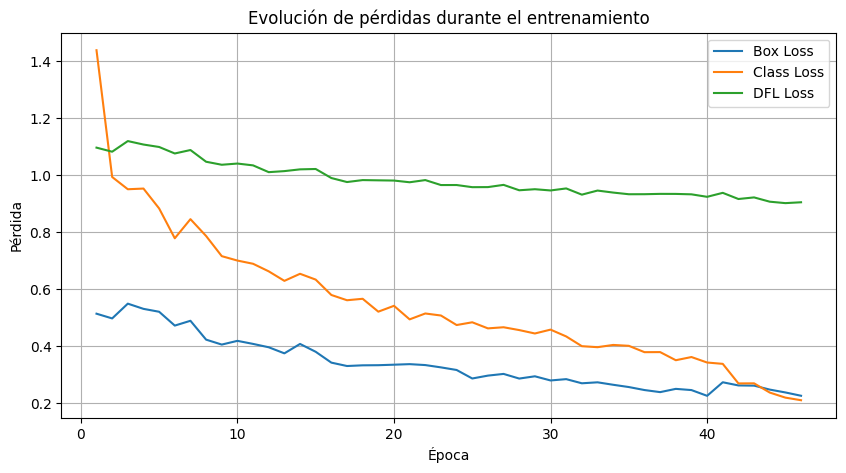

In [9]:
plt.figure(figsize=(10,5))
plt.plot(df["epoch"], df["train/box_loss"], label="Box Loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="Class Loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="DFL Loss")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Evolución de pérdidas durante el entrenamiento")
plt.legend()
plt.grid()
plt.show()

## 7. Visualización de métricas mAP

En esta sección se grafican las métricas `mAP50` y `mAP50-95` obtenidas durante el entrenamiento. Estas métricas permiten evaluar la precisión del modelo en la detección de objetos a lo largo de las épocas.

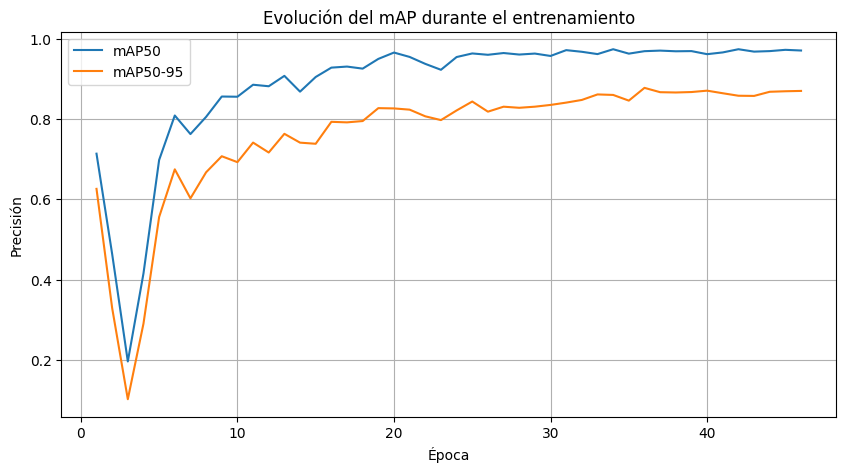

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.title("Evolución del mAP durante el entrenamiento")
plt.legend()
plt.grid()
plt.show()

## 8. Prueba del modelo con una imagen externa

En esta sección se realiza una prueba de predicción utilizando una imagen externa al entrenamiento. El objetivo es observar cómo responde el modelo entrenado ante una nueva imagen y verificar si logra detectar correctamente las clases aprendidas.

In [13]:
model.predict(
    source="normal1.jpg",
    conf=0.25,
    save=True,
    show=True
)


image 1/1 c:\Users\User\Desktop\EXP4\normal1.jpg: 384x640 (no detections), 81.2ms
Speed: 1.6ms preprocess, 81.2ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\User\Desktop\EXP4\runs\detect\predict-2


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'normal', 1: 'robo'}
 obb: None
 orig_img: array([[[102, 147, 198],
         [104, 148, 195],
         [110, 147, 191],
         ...,
         [ 13,   9,  20],
         [ 13,   9,  21],
         [ 13,   9,  21]],
 
        [[102, 145, 196],
         [105, 147, 194],
         [111, 149, 191],
         ...,
         [ 16,  14,  26],
         [ 19,  15,  27],
         [ 18,  16,  28]],
 
        [[111, 152, 201],
         [111, 152, 197],
         [116, 151, 194],
         ...,
         [ 21,  21,  35],
         [ 25,  22,  37],
         [ 24,  24,  38]],
 
        ...,
 
        [[ 51,  62,  66],
         [ 38,  48,  55],
         [ 36,  42,  53],
         ...,
         [ 29,  31,  32],
         [ 27,  29,  30],
         [ 30,  32,  33]],
 
        [[ 56,  68,  70],
         [ 47,  58,  62],
         [ 43,  49,  62],
         ...,
       

## 9. Evaluación mediante reporte de clasificación

En esta sección se genera un reporte de clasificación a partir de las predicciones realizadas sobre el conjunto de validación. Para ello, se comparan las clases reales obtenidas desde los archivos de etiquetas con las clases predichas por el modelo entrenado.

In [2]:
from ultralytics import YOLO
from sklearn.metrics import classification_report
import os

# Cargar modelo entrenado
model = YOLO("runs/detect/deteccion_robo/weights/best.pt")

# Clases reales y predichas
y_true = []
y_pred = []

# Ruta de validación
labels_path = "dataset/valid/labels"
images_path = "dataset/valid/images"

# Recorrer imágenes
for image_name in os.listdir(images_path):

    image_path = os.path.join(images_path, image_name)

    # Predicción
    results = model.predict(image_path, conf=0.25, verbose=False)

    # Clase predicha
    if len(results[0].boxes) > 0:
        pred_class = int(results[0].boxes.cls[0])
    else:
        pred_class = -1

    # Leer etiqueta real
    label_file = os.path.join(
        labels_path,
        image_name.replace(".jpg", ".txt").replace(".png", ".txt")
    )

    if os.path.exists(label_file):
        with open(label_file, "r") as f:
            line = f.readline().strip()

            if line:
                true_class = int(line.split()[0])

                y_true.append(true_class)
                y_pred.append(pred_class)

# Mostrar reporte
target_names = ["normal", "robo"]

print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

      normal       0.93      0.98      0.96       101
        robo       0.97      0.89      0.93        66

    accuracy                           0.95       167
   macro avg       0.95      0.94      0.94       167
weighted avg       0.95      0.95      0.95       167

